In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
users_df = pd.read_csv('takehome_users.csv', encoding='latin1')
engagement_df = pd.read_csv('takehome_user_engagement.csv')

In [4]:
users_df.shape

(12000, 10)

In [5]:
users_df.describe()

,object_id,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
count,12000.00000,8.823000e+03,12000.000000,12000.000000,12000.000000,6417.000000
mean,6000.50000,1.379279e+09,0.249500,0.149333,141.884583,5962.957145
std,3464.24595,1.953116e+07,0.432742,0.356432,124.056723,3383.761968
min,1.00000,1.338452e+09,0.000000,0.000000,0.000000,3.000000
25%,3000.75000,1.363195e+09,0.000000,0.000000,29.000000,3058.000000
50%,6000.50000,1.382888e+09,0.000000,0.000000,108.000000,5954.000000
75%,9000.25000,1.398443e+09,0.000000,0.000000,238.250000,8817.000000
max,12000.00000,1.402067e+09,1.000000,1.000000,416.000000,11999.000000


In [6]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  object 
 2   name                        12000 non-null  object 
 3   email                       12000 non-null  object 
 4   creation_source             12000 non-null  object 
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 937.6+ KB


In [7]:
engagement_df.shape

(207917, 3)

In [8]:
engagement_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   time_stamp  207917 non-null  object
 1   user_id     207917 non-null  int64 
 2   visited     207917 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.8+ MB


In [9]:
users_df.describe()

,object_id,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
count,12000.00000,8.823000e+03,12000.000000,12000.000000,12000.000000,6417.000000
mean,6000.50000,1.379279e+09,0.249500,0.149333,141.884583,5962.957145
std,3464.24595,1.953116e+07,0.432742,0.356432,124.056723,3383.761968
min,1.00000,1.338452e+09,0.000000,0.000000,0.000000,3.000000
25%,3000.75000,1.363195e+09,0.000000,0.000000,29.000000,3058.000000
50%,6000.50000,1.382888e+09,0.000000,0.000000,108.000000,5954.000000
75%,9000.25000,1.398443e+09,0.000000,0.000000,238.250000,8817.000000
max,12000.00000,1.402067e+09,1.000000,1.000000,416.000000,11999.000000


In [10]:
print(users_df.isnull().sum())


object_id                        0
creation_time                    0
name                             0
email                            0
creation_source                  0
last_session_creation_time    3177
opted_in_to_mailing_list         0
enabled_for_marketing_drip       0
org_id                           0
invited_by_user_id            5583
dtype: int64


In [11]:


users_df['last_session_creation_time'] = users_df['last_session_creation_time'].fillna(users_df['last_session_creation_time'].mean())
users_df['invited_by_user_id'] = users_df['invited_by_user_id'].fillna(users_df['invited_by_user_id'].mean())

print(users_df.isnull().sum())

object_id                     0
creation_time                 0
name                          0
email                         0
creation_source               0
last_session_creation_time    0
opted_in_to_mailing_list      0
enabled_for_marketing_drip    0
org_id                        0
invited_by_user_id            0
dtype: int64


In [12]:

print(engagement_df.isnull().sum())

time_stamp    0
user_id       0
visited       0
dtype: int64


## Convert timestamps

In [13]:
users_df.dtypes

object_id                       int64
creation_time                  object
name                           object
email                          object
creation_source                object
last_session_creation_time    float64
opted_in_to_mailing_list        int64
enabled_for_marketing_drip      int64
org_id                          int64
invited_by_user_id            float64
dtype: object

In [14]:
engagement_df.dtypes

time_stamp    object
user_id        int64
visited        int64
dtype: object

In [15]:
engagement_df['time_stamp'] = pd.to_datetime(engagement_df['time_stamp'])



In [16]:

from datetime import timedelta

users = set()

for user_id, group in engagement_df.groupby('user_id'):
    dates = group['time_stamp'].sort_values()
    for i in range(len(dates) - 2):
        if (dates.iloc[i+2] - dates.iloc[i]).days <= 7:
            users.add(user_id)
            break

In [17]:
users_df.columns

Index(['object_id', 'creation_time', 'name', 'email', 'creation_source',
       'last_session_creation_time', 'opted_in_to_mailing_list',
       'enabled_for_marketing_drip', 'org_id', 'invited_by_user_id'],
      dtype='object')

In [18]:
users_df.columns

Index(['object_id', 'creation_time', 'name', 'email', 'creation_source',
       'last_session_creation_time', 'opted_in_to_mailing_list',
       'enabled_for_marketing_drip', 'org_id', 'invited_by_user_id'],
      dtype='object')

In [19]:
users_df['is_adopted'] = users_df['object_id'].isin(users).astype(int)



In [20]:
features = users_df.drop(columns=['name', 'email', 'invited_by_user_id', 'opted_in_to_mailing_list',
                               'enabled_for_marketing_drip', 'object_id', 'is_adopted'])
features = pd.get_dummies(features, drop_first=True)
features.fillna(features.mean(), inplace=True)

target = users_df['is_adopted']

In [21]:
# Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42, stratify=target # Stratify to handle class imbalance
)


In [22]:
# Scale the data for better performance with Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])



In [23]:
# Train the Logistic Regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [25]:
# Print evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision Score:", precision_score(y_test, y_pred))
print("Recall Score:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8697222222222222
Precision Score: 0.7333333333333333
Recall Score: 0.08853118712273642
F1 Score: 0.15798922800718132

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.99      0.93      3103
           1       0.73      0.09      0.16       497

    accuracy                           0.87      3600
   macro avg       0.80      0.54      0.54      3600
weighted avg       0.85      0.87      0.82      3600



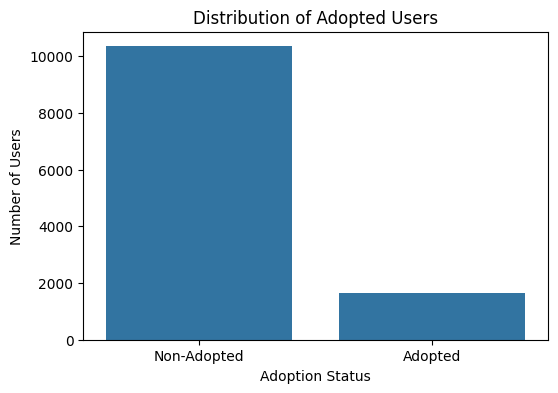

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(x='is_adopted', data=users_df)
plt.title('Distribution of Adopted Users')
plt.xticks([0, 1], ['Non-Adopted', 'Adopted'])
plt.xlabel('Adoption Status')
plt.ylabel('Number of Users')
plt.show()

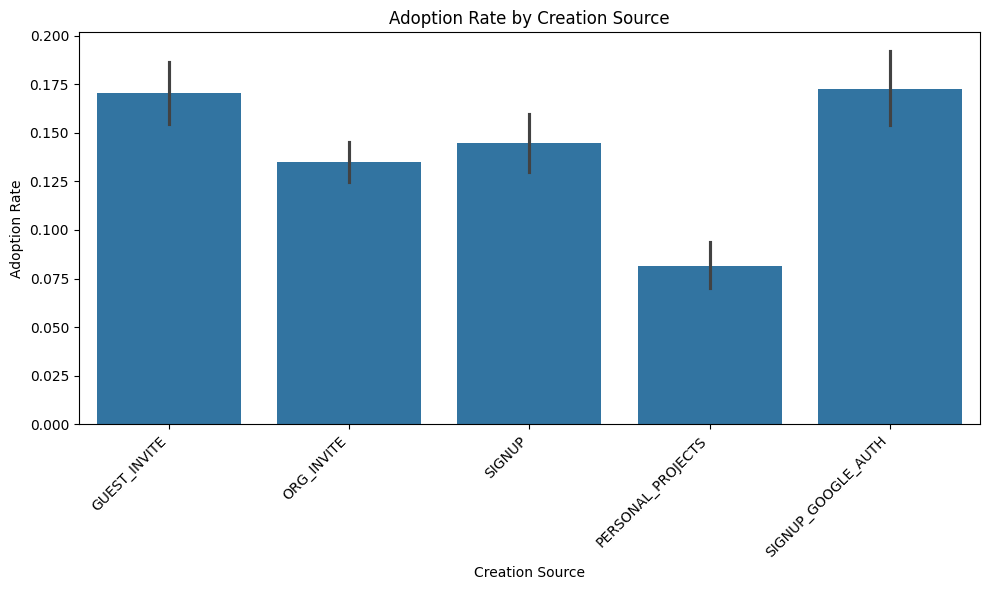

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='creation_source', y='is_adopted', data=users_df)
plt.title('Adoption Rate by Creation Source')
plt.xlabel('Creation Source')
plt.ylabel('Adoption Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()